# I. Разминка numpy (1 балл)

## 1. Парсеки

Напишите функцию, которая принимает на вход:
- np.array - набор расстояний от Земли до звёзд (в световых годах)
- k - количество значений, которое нам нужно

Выведите топ-k самых удаленных звёзд от нас в порядке убывания разрастания, расстояния выведите в парсеках (1 парсек приблизительно равен 3.262 световым годам)

In [ ]:

import numpy as np
def find_top_k_longest_distance_stars(a,k):
  d=list(map(float, a))
  d.sort()
  d=d[:len(d)-1-k:-1]
  return d



In [ ]:
import numpy as np
print(find_top_k_longest_distance_stars(np.array([4.37, 8.6, 4.24, 4.37, 5.96, 7.8, 8.6, 7.9]), 4))

[8.6, 8.6, 7.9, 7.8]


## 2. Оцениваем размер галактики

Напишите функцию, которая принимает на вход:
- np.array - набор масс звёзд в галактике
- k - количество максимальных по массе звёзд

Функция должна вывести два числа - первое - сумму масс первых k звёзд по массе, второе - сумму масс остальных звёзд.

In [ ]:
def count_k_masses(a,k):
  d=list(map(int, a))
  d.sort()
  big=d[:len(d)-1-k:-1]
  small=d[len(d)-1-k::-1]
  return sum(big), sum(small)

In [ ]:
# Просто пример, можно придумать свой
print(count_k_masses(np.array([150, 200, 300, 250, 400, 100, 200]), 2))

(700, 900)


# II. Помогаем Карелии

## 0. Загрузи датасет в этот блокнот (0.5 балла)

Открой гугл-диск курса, разархивируй zip-архив и собери нужные наборы данных из архива в единый датасет при помощи pandas.

In [ ]:
import numpy as np
import pandas as pd
#я разделила считывание годов на 2 части, так как с 2015 года страницы расходов и доходов меняются местами в excel

for i in ['2010.xlsx', '2011.xlsx','2012.XLS', '2013.xls', '2014.XLS']:
  if i == '2010.xlsx' or i=='2011.xlsx':
    income=pd.read_excel(i, sheet_name=0)
    spendings=pd.read_excel(i, sheet_name=1)
  else:#в этих годах из-за формата первая страница - техническая
    income=pd.read_excel(i, sheet_name=1)
    spendings=pd.read_excel(i, sheet_name=2)
  income=income.drop_duplicates()#я сразу начинаю убирать дупликаты, потому что в противном случае не хватает опервтивной памяти ноутбука
  spendings=spendings.drop_duplicates()
  income.rename(columns={"Unnamed: 0": "Наименование показателя", " Наименование показателя": "Наименование показателя", 'бюджет субъекта Российской Федерации': i[:4], "Unnamed: 3": i[:4], "BI Publisher Version": "Наименование показателя","(1) Наименование показателя": "Наименование показателя", '(21) Исполнено, бюджет субъекта РФ': i[:4]}, inplace=True)#вручную делаю так чтобы все столбцы правильно считывались вне зависимости от того, как они были названы в таблицах
  incplace=['доходы'] * len(income.index)#тут и позже делаю столбик, который будет показывать к чему относится эта строка
  income['Where'] = incplace
  df_i = income[['Where', 'Наименование показателя', i[:4]]]#таблица только доходов только из 3 нужных столбцов
  df_i= df_i.drop([0,1])#убираю ненужную строку и повторяю тоже для расходлв
  spendings.rename(columns={"Unnamed: 0": "Наименование показателя","Unnamed: 6": i[:4], "Бюджет субъекта Российской Федерации": i[:4], "бюджет субъекта Российской Федерации": i[:4]}, inplace=True)
  spendplace=['расходы'] * len(spendings.index)
  spendings['Where'] = spendplace
  df_s = spendings[['Where','Наименование показателя', i[:4]]]
  df_s=df_s.drop_duplicates()#опять удаляю дупликаты
  df_i=df_i.drop_duplicates()
  result = pd.concat([df_i, df_s],sort=False)#приклеиваю расходы под доходами (теперь одна таблица)
  result = result.drop_duplicates()
  result = result.dropna()#удаляю NaN
  if i=='2010.xlsx':
    final1=result
  else:
    final1 = pd.merge(final1, result, left_on=['Where', 'Наименование показателя'],
                  right_on=['Where', 'Наименование показателя'], how='left')#делаю общую таблицу для первых годов
  final1=final1.drop_duplicates(subset='Наименование показателя')
#то же самое для оставшихся годов
for j in ['2015.xls', '2016.xlsx', '2017.xlsx', '2018.xlsx', '2019.xlsx', '2020.xlsx']:
  income=pd.read_excel(j, sheet_name=1)
  spendings=pd.read_excel(j, sheet_name=0)
  income.rename(columns={" Наименование показателя": "Наименование показателя", "Unnamed: 3": j[:4], "BI Publisher Version": "Наименование показателя","(1) Наименование показателя": "Наименование показателя", '(21) Исполнено, бюджет субъекта РФ': j[:4], "Unnamed: 0": "Наименование показателя", 'бюджет субъекта Российской Федерации':j[:4]}, inplace=True)
  incplace=['доходы'] * len(income.index)
  income['Where'] = incplace
  df_i = income[['Where', 'Наименование показателя', j[:4]]]
  df_i = df_i.dropna()
  spendplace=['расходы'] * len(spendings.index)
  spendings['Where'] = spendplace
  spendings.rename(columns={"Unnamed: 0": "Наименование показателя", "Бюджет субъекта Российской Федерации": j[:4], "бюджет субъекта Российской Федерации": j[:4], 'Unnamed: 5': j[:4], 'BI Publisher Version': "Наименование показателя",  '(1) Наименование показателя': "Наименование показателя", '(21) Исполнено, бюджет субъекта РФ': j[:4] }, inplace=True)
  df_s = spendings[['Where', 'Наименование показателя', j[:4]]]
  result = pd.concat([df_i, df_s],sort=False)
  result = result.drop_duplicates()
  if j=='2015.xls':
    final2=result
  else:
   final2 = pd.merge(final2, result, left_on=['Where', 'Наименование показателя'],
                  right_on=['Where', 'Наименование показателя'], how='left')
#соединяю 2010-2014 и 2015-2020 годы
final = pd.merge(final1, final2, left_on=['Where', 'Наименование показателя'],
                  right_on=['Where', 'Наименование показателя'], how='left')
#добавляю общие показатели
final.loc[len(final)] = ['this year','Total expences', 25641875414.57, 27631246903.81, 29140749888.23, 28754420604.42, 31039085086.34, 31356669427.82, 34508364905.09, 36810091699.46, 43076921835.03, 50268395809.96, 67616189896.19]
final.loc[len(final)] = ['this year','Total income', 24873441175.45, 27556466680.93, 26893154749.54, 23984242603.04, 27750206180.02, 28390875283.93, 32546447594.29, 34385355496.24, 47268601337.1, 51272761265.22, 60597379486.3]
final.loc[len(final)] = ['next year', 'Next year Total expences',  27631246903.81, 29140749888.23, 28754420604.42, 31039085086.34, 31356669427.82, 34508364905.09, 36810091699.46, 43076921835.03, 50268395809.96, 67616189896.19, (67616189896.19+50268395809.96+43076921835.03+36810091699.46+34508364905.09+31356669427.82+31039085086.34+28754420604.42+29140749888.23+27631246903.81)/10]
final.loc[len(final)] = ['next year', 'Next year Total income',  27556466680.93, 26893154749.54, 23984242603.04, 27750206180.02, 28390875283.93, 32546447594.29, 34385355496.24, 47268601337.1, 51272761265.22, 60597379486.3, (27556466680.93+26893154749.54+23984242603.04+27750206180.02+28390875283.93+32546447594.29+34385355496.24+47268601337.1+51272761265.22+60597379486.3)/10]



final = final.set_index('Наименование показателя')#делаю названия индексом
final

,Where,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Наименование показателя,,,,,,,,,,,,
Доходы бюджета - Всего,доходы,24873441175.450001,27556466680.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ,доходы,15322132232.73,18202689345.18,17570424288.029999,15173763025.93,1.595676e+10,1.780816e+10,19654412574.419998,20129196349.220001,26604349315.43,27763981934.919998,27131141282.57
"НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ",доходы,8613483384.459999,11334538970.16,10813732699.530001,8101885886.87,8.916328e+09,9.962889e+09,11518070774.48,11700807336.309999,16900358608,17336881098.560001,15165765187.879999
Налог на прибыль организаций,доходы,3980212142.4,6262562069.63,5279887784.7,2200021502.01,1.837840e+09,3.114014e+09,4280042099.75,4022683492.19,8128882485.27,8162340492.33,5058407816.68
"Налог на прибыль организаций, зачисляемый в бюджеты бюджетной системы Российской Федерации по соответствующим ставкам",доходы,3980212142.4,6262562069.63,5279887784.7,2200021502.01,1.837840e+09,3.114014e+09,4280042099.75,4022683492.19,8128882485.27,8162340492.33,5058407816.68
...,...,...,...,...,...,...,...,...,...,...,...,...
"Результат исполнения бюджета (дефицит ""--"", профицит ""+"")",расходы,-768434239.12,-74780222.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total expences,this year,25641875414.57,27631246903.810001,29140749888.23,28754420604.419998,3.103909e+10,3.135667e+10,34508364905.089996,36810091699.459999,43076921835.029999,50268395809.959999,67616189896.190002
Total income,this year,24873441175.450001,27556466680.93,26893154749.540001,23984242603.040001,2.775021e+10,2.839088e+10,32546447594.290001,34385355496.239998,47268601337.099998,51272761265.220001,60597379486.300003


In [ ]:

#оно просто случайно есть

,Where,Наименование показателя,2013
2,доходы,в том числе:,NaN
3,доходы,НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ,1.595676e+10
4,доходы,"НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ",8.916328e+09
5,доходы,Налог на прибыль организаций,1.837840e+09
6,доходы,"Налог на прибыль организаций, зачисляемый в бю...",1.837840e+09
...,...,...,...
954,расходы,Перечисления другим бюджетам бюджетной системы...,5.000000e+06
955,расходы,Прочие межбюджетные трансферты общего характера,5.907210e+08
956,расходы,Расходы,5.907210e+08
957,расходы,Безвозмездные перечисления бюджетам,5.907210e+08


## 1. Предобработка датасета (2 балла)

- изучи датасет
- очисти данные в нём (есть ли в нём пропуски и выбросы? что ты можешь с ними сделать? сделай это.)

In [ ]:

def cleared(df):
  df = df.drop_duplicates()#удаляю дупликаты
  for i in df.iterrows():
    if i[1].isna().sum()>=6:#если больше 6 NaN, то удаляю строку
      df = df.drop([i[1].name])
    else:#если мешьше то вставляю медианное значение
      mid= i[1][2::].median()
      df.loc[[i[1].name]]= df.loc[[i[1].name]].infer_objects(copy=False).fillna(value=mid)
  return df

final = cleared(final)
final

,Where,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Наименование показателя,,,,,,,,,,,,
НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ,доходы,15322132232.73,18202689345.18,17570424288.029999,15173763025.93,1.595676e+10,1.780816e+10,19654412574.419998,20129196349.220001,26604349315.43,27763981934.919998,27131141282.57
"НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ",доходы,8613483384.459999,11334538970.16,10813732699.530001,8101885886.87,8.916328e+09,9.962889e+09,11518070774.48,11700807336.309999,16900358608,17336881098.560001,15165765187.879999
Налог на прибыль организаций,доходы,3980212142.4,6262562069.63,5279887784.7,2200021502.01,1.837840e+09,3.114014e+09,4280042099.75,4022683492.19,8128882485.27,8162340492.33,5058407816.68
"Налог на прибыль организаций, зачисляемый в бюджеты субъектов Российской Федерации",доходы,3980213558.01,6262518004.63,5279864760.7,2200021502.01,1.837840e+09,2.589451e+09,2589450837.68,2589450837.68,2589450837.68,2589450837.68,2589450837.68
Налог на доходы физических лиц,доходы,4633271242.06,5071976900.53,5533844914.83,5901864384.86,7.078488e+09,6.848875e+09,7238028674.73,7678123844.12,8771476122.73,9174540606.23,10107357371.200001
...,...,...,...,...,...,...,...,...,...,...,...,...
Перечисления другим бюджетам бюджетной системы Российской Федерации,расходы,8409842392.39,17919084.09,0,23815517.94,2.394250e+07,2.086730e+07,20867301.015,20867301.015,20867301.015,20867301.015,20867301.015
Total expences,this year,25641875414.57,27631246903.810001,29140749888.23,28754420604.419998,3.103909e+10,3.135667e+10,34508364905.089996,36810091699.459999,43076921835.029999,50268395809.959999,67616189896.190002
Total income,this year,24873441175.450001,27556466680.93,26893154749.540001,23984242603.040001,2.775021e+10,2.839088e+10,32546447594.290001,34385355496.239998,47268601337.099998,51272761265.220001,60597379486.300003


## 2. Найди параметры, которые влияют на бюджет (3.5 балла)

Поэкспериментируй с параметрами, найди 3 параметра, которые сильно связаны с значением бюджета Карелии за год (тут есть две цифры - расходы бюджета ИТОГО и доходы бюджета ИТОГО - искать параметры надо к обоим на основе **предыдущего года**) (при помощи коэффициента корреляции). Настоятельно рекомендуем поиграть с разными параметрами  - попробовать линейные комбинации, некоторые функции от параметров (log, возведение в степень, etc).

Оставь весь код экспериментов в этом блоке, но в конце опиши, какие параметры в итоге ты берёшь.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
iy=final.loc['Next year Total income'].drop('Where')
iy_list = iy.tolist()#делаю lists
sy=final.loc['Next year Total expences'].drop('Where')
sy_list = sy.tolist()
for i in final.iterrows():#делаю перебор по строчкам
  if i[1].loc['Where']=='доходы':
    if isinstance(i[1], pd.DataFrame):
      final=final.drop(final.loc[i[1].name])
    broken_list = i[1].tolist()[1:]#создаю lists только из численных значений построчно
    c = np.corrcoef(iy_list, broken_list)#считаю корреляцию
    siy = np.array(iy_list).reshape(1, -1)
    sbr = np.array(broken_list).reshape(1, -1)
    sim = cosine_similarity(siy, sbr)[0][0]#считаю коэффициент Отаи
    a=c[0][1]
    if a>0.85:
      print(i[1].name, 'income', a)
    if sim>0.98:
      print(i[1].name, 'income', sim, 'sim')
  if i[1].loc['Where']=='расходы':#аналогично для расходов
    if isinstance(i[1], pd.DataFrame):
      final=final.drop(final.loc[i[1].name])
    broken_list = i[1].tolist()[1:]
    ssy = np.array(sy_list).reshape(1, -1)
    sbr = np.array(broken_list).reshape(1, -1)
    sim = cosine_similarity(ssy, sbr)[0][0]
    c = np.corrcoef(sy_list, broken_list)
    a=c[0][1]
    if a<-0.9:
      print(i[1].name, 'spendings', a)
    if sim>0.961:
      print(i[1].name, 'spendings', sim, 'sim')



НАЛОГОВЫЕ И НЕНАЛОГОВЫЕ ДОХОДЫ income 0.9838433701592626 siim
НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ income 0.9854152515486934 siim
Акцизы на пиво, производимое на территории Российской Федерации income 0.8711318912456129
Транспортный налог income 0.9804565944186892 siim
ГОСУДАРСТВЕННАЯ ПОШЛИНА income 0.898189129614106
Государственная пошлина за государственную регистрацию, а также за совершение прочих юридически значимых действий income 0.8960902158563863
Государственная пошлина за совершение действий, связанных с лицензированием, с проведением аттестации в случаях, если такая аттестация предусмотрена законодательством Российской Федерации income 0.8584503959836395
Доходы в виде прибыли, приходящейся на доли в уставных (складочных) капиталах хозяйственных товариществ и обществ, или дивидендов по акциям, принадлежащим Российской Федерации, субъектам Российской Федерации или муниципальным образованиям income 0.8742618023305709
Дотации на выравнивание бюджетной обеспеченности income 0.881481524924742

/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]




---
<font color="violet">
Для расходов



---

<font color="pink">

1.  Защита населения и территории от чрезвычайных ситуаций природного и техногенного характера, гражданская оборона
2.   Национальная экономика
3. Кинематография



---

<font color="violet">
Для доходов


---

<font color="pink">


1.   Налоги и прибыль, доходы
2.   Акцизы на пиво, производимое на территории Российской Федерации
3. Транспортный налог
4. Гocударственная пошлина




</font>

# 3. Графики (1 балл)

Построй графики с выбранными параметрами и бюджетом Карелии. Что ты на них видишь?

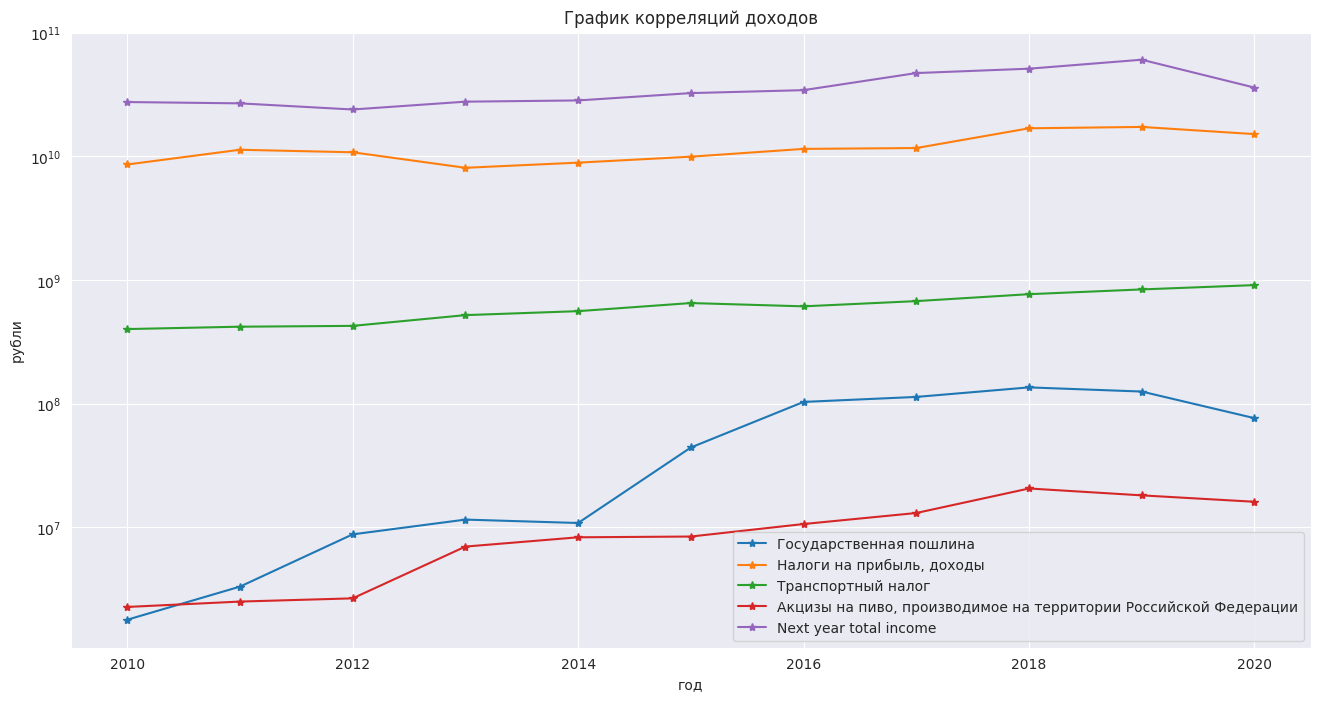

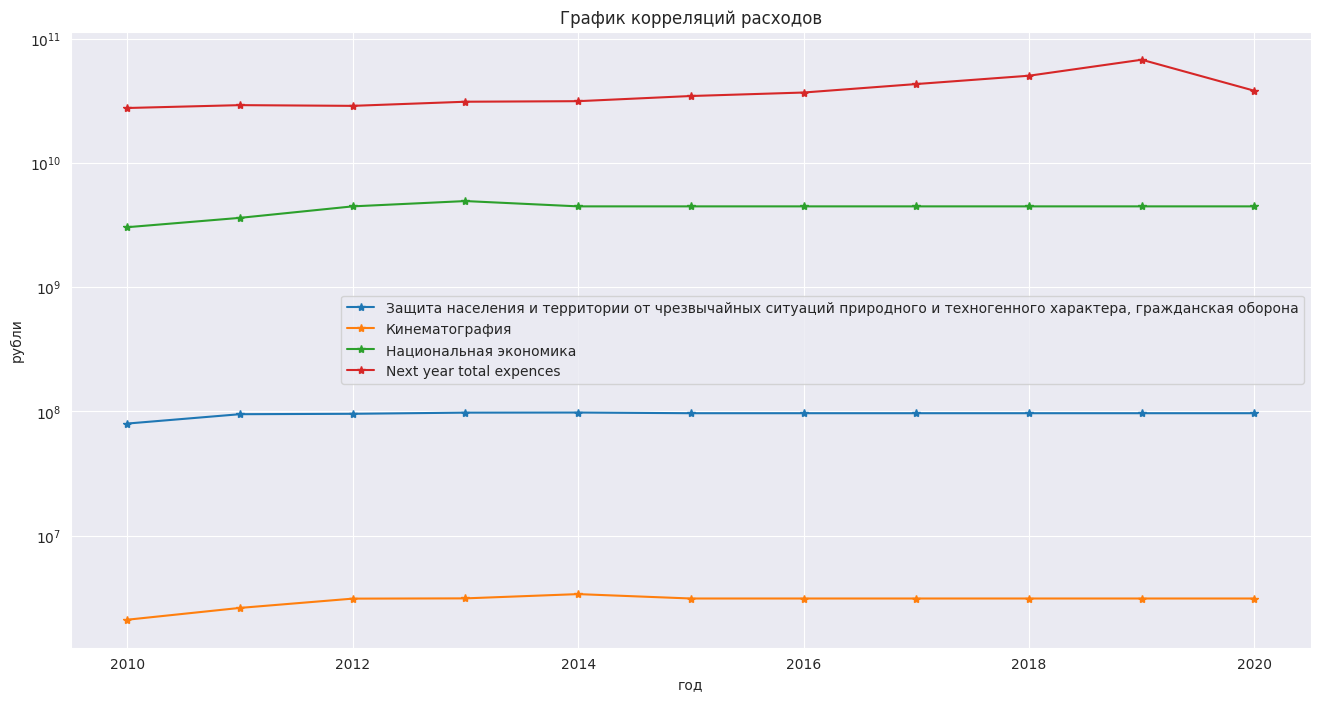

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.scale as mscale
import seaborn as sns

#создаю списки для этих параметров
one=final.loc['ГОСУДАРСТВЕННАЯ ПОШЛИНА'].tolist()[1:]
two=final.loc['НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ'].tolist()[1:]
three=final.loc['Транспортный налог'].tolist()[1:]
five=final.loc['Защита населения и территории от чрезвычайных ситуаций природного и техногенного характера, гражданская оборона'].tolist()[1:]
four=final.loc['Акцизы на пиво, производимое на территории Российской Федерации'].tolist()[1:]
six=final.loc['Кинематография'].tolist()[1:]
seven=final.loc['Национальная экономика'].tolist()[1:]
axis=[2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]
#dictionary из всех элементов
prep = {'Next year Total income': iy, '1': one, '2': two, '3': three, '4': four, 'year': axis}
matrix = pd.DataFrame(prep)#делаю датафрейм
sns.set_style('darkgrid')#делаю квадратика
plt.subplots(figsize=(16, 8))#создаю пространство
x = matrix['year']
y= matrix['Next year Total income']
plt.yscale('log')
y_1 = matrix['1']
y_2 = matrix['2']
y_3 = matrix['3']
y_4 = matrix['4']
plt.plot(x, y_1, marker='*', label='Гocударственная пошлина')#рисую графчики
plt.plot(x, y_2, marker='*', label='Налоги на прибыль, доходы')
plt.plot(x, y_3, marker='*', label='Транспортный налог')
plt.plot(x, y_4, marker='*', label='Акцизы на пиво, производимое на территории Российской Федерации')
plt.plot(x, y, marker='*', label='Next year total income')

plt.title(r'График корреляций доходов', fontsize=12)#подписывю всё
plt.xlabel(r'год', fontsize=10)
plt.ylabel(r'рубли', fontsize=10)

plt.legend(loc='best')#печатаю легенду
plt.show()#график появляется (чистая магия)
#всё также для расходов
prep2 = {'Next year Total expences': sy, '5': five, '6': six, '7': seven, 'year': axis}
matrix2 = pd.DataFrame(prep2)

sns.set_style('darkgrid')
plt.subplots(figsize=(16, 8))
x = matrix2['year']
y= matrix2['Next year Total expences']
plt.yscale('log')
y_5 = matrix2['5']
y_6 = matrix2['6']
y_7 = matrix2['7']

plt.plot(x, y_5, marker='*', label='Защита населения и территории от чрезвычайных ситуаций природного и техногенного характера, гражданская оборона')
plt.plot(x, y_6, marker='*', label='Кинематография')
plt.plot(x, y_7, marker='*', label='Национальная экономика')
plt.plot(x, y, marker='*', label='Next year total expences')
plt.title(r'График корреляций расходов', fontsize=12)
plt.xlabel(r'год', fontsize=10)
plt.ylabel(r'рубли', fontsize=10)

plt.legend(loc='best')
plt.show()


In [ ]:
# TODO

## 4. Анализ параметров (2 балла)

На основе графиков и самих параметров, расскажи:

- Построй гипотезы, наблюдаешь ли ты казуацию или здесь просто совпадение?
- Предложи гипотезы, как проверить, нет ли ошибок в твоих выводах
- Проанализируй взаимосвязь с параметрами между собой. Являются ли они сильноскореллированными? Имеет ли смысл использовать их всех вместе или достаточно одного?

In [ ]:
one=final.loc['ГОСУДАРСТВЕННАЯ ПОШЛИНА'].tolist()[1:]
two=final.loc['НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ'].tolist()[1:]
three=final.loc['Транспортный налог'].tolist()[1:]
five=final.loc['Защита населения и территории от чрезвычайных ситуаций природного и техногенного характера, гражданская оборона'].tolist()[1:]
four=final.loc['Акцизы на пиво, производимое на территории Российской Федерации'].tolist()[1:]
six=final.loc['Кинематография'].tolist()[1:]
seven=final.loc['Национальная экономика'].tolist()[1:]
lop=['ГОСУДАРСТВЕННАЯ ПОШЛИНА', 'НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ', 'Акцизы на пиво, производимое на территории Российской Федерации', 'Транспортный налог','Защита населения и территории от чрезвычайных ситуаций природного и техногенного характера, гражданская оборона', 'Кинематография', 'Национальная экономика' ]
lis=[one, two, three, four, five, six, seven]

hyt = pd.DataFrame(lis)
hyt = hyt.T
hyt.columns = [i for i in lop]
correlation_matrix = hyt.corr()
correlation_matrix

,ГОСУДАРСТВЕННАЯ ПОШЛИНА,"НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ","Акцизы на пиво, производимое на территории Российской Федерации",Транспортный налог,"Защита населения и территории от чрезвычайных ситуаций природного и техногенного характера, гражданская оборона",Кинематография,Национальная экономика
ГОСУДАРСТВЕННАЯ ПОШЛИНА,1.000000,0.800016,0.796585,0.904792,0.354511,0.381043,0.375789
"НАЛОГИ НА ПРИБЫЛЬ, ДОХОДЫ",0.800016,1.000000,0.790227,0.837280,0.295452,0.244153,0.199217
"Акцизы на пиво, производимое на территории Российской Федерации",0.796585,0.790227,1.000000,0.929261,0.452298,0.505417,0.483676
Транспортный налог,0.904792,0.837280,0.929261,1.000000,0.442121,0.500546,0.482880
"Защита населения и территории от чрезвычайных ситуаций природного и техногенного характера, гражданская оборона",0.354511,0.295452,0.452298,0.442121,1.000000,0.916304,0.871601
Кинематография,0.381043,0.244153,0.505417,0.500546,0.916304,1.000000,0.929698
Национальная экономика,0.375789,0.199217,0.483676,0.482880,0.871601,0.929698,1.000000


<font color="violet">
расходы

---
<font color="pink">
Про расходы в Корелии можно сказать, что они едва ли менялись за эти года, поэтому сказать про графики можно совсем немного. Совпадение корреляции кинематографии и защты населения явно просто совпадения, так как вряд ли Корелия тратит достаточное колтчеставо денег (это видно по графикам). Национальная экономика скорее всего как-то влияет, но сказать точно ничего нельзя, так как она очень похожа на прямую линию.


---
<font color="violet">
доходы


---
<font color="pink">
Налоги на прибыль не казуальная корреляция. Так как они составляют максимальную долю доходов Корелии.
Транспортный налог- это совпадение, потому что они почти не меняются
Аксцизы на пиво слишком маленькие, чтобы на что-то влиять.
А вот увеоичение гос пошлин могло повлиять на увеличение доходов с небольшой задержкой.


---
<font color="violet">
проверка гипотез


---
<font color="pink">
Во-первых, стоит проверить теорию на бОльшей выборке лет. Во-вторых, можно попробовать построить модель машинного обучения, чтобы предсказывать лучше, как оно всё взаимосвязано.


---
<font color="pink">
Мне не кажется, что корреляционная матрица принесла мне лучшее понимание регииона, так как ожидаемо доходы тесно коррелируют с дрегими доходами, но не с расходами. Возможно стоит смотреть расходы с опозданием в год, так как люди посмотрели и поняли, что им надо меньше иои больше тратить в результати смет прошлого года.


---

Хорошего Вам дня! :)


